In [3]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
import time
import neuralop
import matplotlib.pyplot as plt
from neuralop.data.datasets import load_darcy_flow_small
from neuralop.layers.embeddings import GridEmbedding2D
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'sim_PyBaMM' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NO/../sim_PyBaMM.py'>

In [4]:
train_loader, test_loaders, data_processor = load_darcy_flow_small(
    n_train=20,
    batch_size=4,
    test_resolutions=[16, 32],
    n_tests=[10, 10],
    test_batch_sizes=[4, 2],
)

train_dataset = train_loader.dataset

Loading test db for resolution 16 with 10 samples 
Loading test db for resolution 32 with 10 samples 


In [5]:
for res, test_loader in test_loaders.items():
    print(f"Resolution: {res}")
    # Get first batch
    batch = next(iter(test_loader))
    x = batch["x"]  # Input
    y = batch["y"]  # Output

    print(f"Testing samples for resolution {res} have shape {x.shape[1:]}")


data = train_dataset[0]
x = data["x"]
y = data["y"]

print(f"Training samples have shape {x.shape[1:]}")

# Which sample to view
index = 0

data = train_dataset[index]
data = data_processor.preprocess(data, batched=False)

# The first step of the default FNO model is a grid-based
# positional embedding. We will add it manually here to
# visualize the channels appended by this embedding.
positional_embedding = GridEmbedding2D(in_channels=1)
# At train time, data will be collated with a batch dimension.
# We create a batch dimension to pass into the embedding, then re-squeeze
x = positional_embedding(data["x"].unsqueeze(0)).squeeze(0)
y = data["y"]

Resolution: 16


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Testing samples for resolution 16 have shape torch.Size([1, 16, 16])
Resolution: 32
Testing samples for resolution 32 have shape torch.Size([1, 32, 32])
Training samples have shape torch.Size([16, 16])


/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_83131/2254824060.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


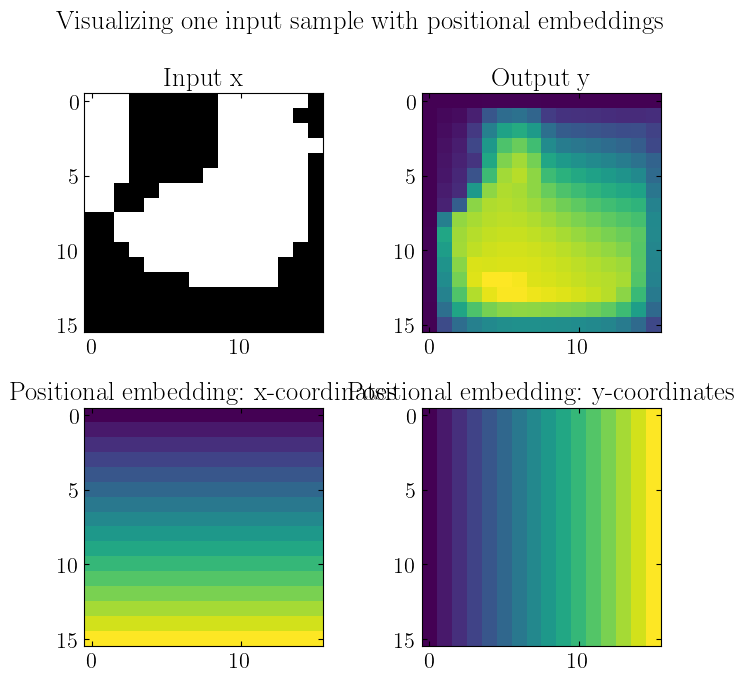

In [6]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(2, 2, 1)
ax.imshow(x[0], cmap="gray")
ax.set_title("Input x")
ax = fig.add_subplot(2, 2, 2)
ax.imshow(y.squeeze())
ax.set_title("Output y")
ax = fig.add_subplot(2, 2, 3)
ax.imshow(x[1])
ax.set_title("Positional embedding: x-coordinates")
ax = fig.add_subplot(2, 2, 4)
ax.imshow(x[2])
ax.set_title("Positional embedding: y-coordinates")
fig.suptitle("Visualizing one input sample with positional embeddings", y=0.98)
plt.tight_layout()
fig.show()